<a href="https://colab.research.google.com/github/Vivekcoder11/Amazon-clone/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



In [7]:
!kaggle datasets download -d imtkaggleteam/dental-opg-xray-dataset


Dataset URL: https://www.kaggle.com/datasets/imtkaggleteam/dental-opg-xray-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
dental-opg-xray-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
!pwd


/content


In [12]:
!ls | head


Dental OPG XRAY Dataset
dental-opg-xray-dataset.zip
drive
kaggle.json
sample_data


In [13]:
!ls images | head


ls: cannot access 'images': No such file or directory


In [14]:
!ls "Dental OPG XRAY Dataset"


'Dental OPG (Classification)'  'Dental OPG (Object Detection)'


In [15]:
!ls "Dental OPG XRAY Dataset/Dental OPG (Classification)"


 BDC-BDR  'Fractured Teeth'  'Impacted teeth'
 Caries   'Healthy Teeth'     Infection


In [17]:
base_dir = "Dental OPG XRAY Dataset/Dental OPG (Classification)"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [18]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)


Found 417 images belonging to 6 classes.
Found 100 images belonging to 6 classes.


In [19]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [21]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.2906 - loss: 2.3930 - val_accuracy: 0.4400 - val_loss: 1.4382
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.3889 - loss: 1.5084 - val_accuracy: 0.4400 - val_loss: 1.4859
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.3581 - loss: 1.5564 - val_accuracy: 0.4400 - val_loss: 1.4730
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4283 - loss: 1.5197 - val_accuracy: 0.4400 - val_loss: 1.4410
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.4177 - loss: 1.4864 - val_accuracy: 0.4400 - val_loss: 1.4424
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4070 - loss: 1.5702 - val_accuracy: 0.4400 - val_loss: 1.4378
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.4476 - loss: 1.5174 - val_accuracy: 0.4400 - val_loss: 1.4762
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.4200 - loss: 1.5257 - val_accuracy: 0.4400 - val_loss:

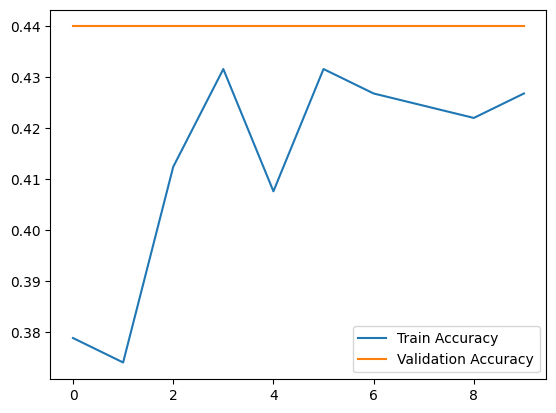

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [23]:
model.save("Dental_OPG_CNN_Model.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


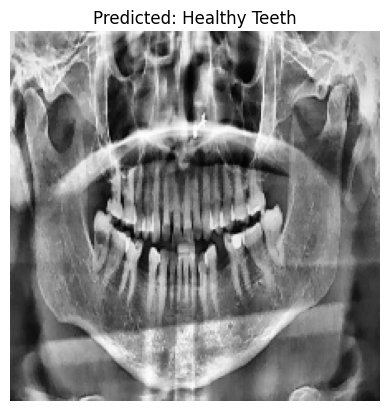

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

base_dir = "Dental OPG XRAY Dataset/Dental OPG (Classification)"

img_path = os.path.join(
    base_dir,
    "Caries",
    os.listdir(os.path.join(base_dir, "Caries"))[1]
)

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
class_names = list(train_data.class_indices.keys())

plt.imshow(img)
plt.title(f"Predicted: {class_names[np.argmax(prediction)]}")
plt.axis('off')
plt.show()
